## Intro

This notebook explores whether regular-season team performance, tournament seeding, and pre-tournament ranking information can help identify NCAA men’s basketball Cinderella teams before the NCAA tournament begins. The analysis uses historical March Machine Learning Mania data and focuses on building a clean team-season dataset for exploratory analysis.

The data used in this project comes from Kaggle’s March Machine Learning Mania competition, which provides historical NCAA men’s basketball regular-season results, tournament seeds, tournament outcomes, and ranking information for predictive modeling. To respect Kaggle’s competition rules, this repository does not redistribute the raw source files and instead assumes that users download the data themselves through Kaggle before running the analysis. From an ethics standpoint, the dataset contains team- and game-level sports records rather than personally identifying information, so privacy concerns are minimal. As a result, the main legal and ethical responsibility in this project is proper use of the competition data and transparent, reproducible analysis rather than protection of sensitive personal data

## Data Loading

The raw Kaggle files are stored at the game and tournament level, so they must be transformed before analysis. The goal of preprocessing is to create one row per Season, TeamID, with regular-season features, tournament seed information, ranking features, and tournament outcomes merged into a single team-season dataset.

The preprocessing pipeline creates a team-season dataset that is more appropriate for exploratory analysis and later modeling. Regular-season statistics are built first, while tournament outcomes are created separately and merged afterward to avoid leakage from postseason results into predictor variables.

In [1]:
# --- Robust, modular rebuild: regular-season features + tournament targets ---

import pandas as pd
from pathlib import Path

def verify_kaggle_mens_columns(dfs_dict: dict) -> None:
    expected = {
        "teams": [
            "TeamID", "TeamName", "FirstD1Season", "LastD1Season"
        ],
        "reg_detailed": [
            "Season", "DayNum", "WTeamID", "WScore", "LTeamID", "LScore", "WLoc", "NumOT",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF"
        ],
        "tourney_seeds": ["Season", "Seed", "TeamID"],
        "tourney_compact": ["Season", "DayNum", "WTeamID", "WScore", "LTeamID", "LScore", "WLoc", "NumOT"],
        "massey": ["Season", "RankingDayNum", "SystemName", "TeamID", "OrdinalRank"],
    }

    for name, cols in expected.items():
        if name not in dfs_dict:
            raise KeyError(f"Missing dataframe '{name}' in dfs.")
        got = list(dfs_dict[name].columns)
        if got != cols:
            missing = [c for c in cols if c not in got]
            extra = [c for c in got if c not in cols]
            raise ValueError(
                f"Column mismatch for '{name}'.\n"
                f"Missing: {missing}\n"
                f"Unexpected: {extra}\n"
                f"Expected order: {cols}\n"
                f"Got order: {got}"
            )

def safe_left_join(left: pd.DataFrame, right: pd.DataFrame, on: list, right_name: str) -> pd.DataFrame:
    if right.duplicated(on).any():
        dup = right[right.duplicated(on, keep=False)].sort_values(on).head(10)
        raise ValueError(f"Right table '{right_name}' has duplicate keys on {on}. Sample:\n{dup}")
    return left.merge(right, on=on, how="left", validate="m:1")


def assert_one_row_per_key(df: pd.DataFrame, keys: list, label: str) -> None:
    dup_count = df.duplicated(keys).sum()
    if dup_count:
        sample = df[df.duplicated(keys, keep=False)].sort_values(keys).head(10)
        raise ValueError(f"{label} has {dup_count} duplicate key rows on {keys}. Sample:\n{sample}")


def build_team_game_rows(reg_df: pd.DataFrame) -> pd.DataFrame:
    stat_fields = ["FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF"]

    w_cols = {
        "Season": "Season", "DayNum": "DayNum", "WTeamID": "TeamID", "LTeamID": "OpponentID",
        "WScore": "PointsFor", "LScore": "PointsAgainst", "NumOT": "NumOT",
    }
    l_cols = {
        "Season": "Season", "DayNum": "DayNum", "LTeamID": "TeamID", "WTeamID": "OpponentID",
        "LScore": "PointsFor", "WScore": "PointsAgainst", "NumOT": "NumOT",
    }

    for s in stat_fields:
        w_cols[f"W{s}"] = s
        w_cols[f"L{s}"] = f"Opp{s}"
        l_cols[f"L{s}"] = s
        l_cols[f"W{s}"] = f"Opp{s}"

    win_rows = reg_df[list(w_cols.keys())].rename(columns=w_cols)
    win_rows["Win"] = 1
    win_rows["Loss"] = 0

    loss_rows = reg_df[list(l_cols.keys())].rename(columns=l_cols)
    loss_rows["Win"] = 0
    loss_rows["Loss"] = 1

    team_games_df = pd.concat([win_rows, loss_rows], ignore_index=True)
    team_games_df["ScoreDiff"] = team_games_df["PointsFor"] - team_games_df["PointsAgainst"]
    team_games_df["Reb"] = team_games_df["OR"] + team_games_df["DR"]
    team_games_df["OppReb"] = team_games_df["OppOR"] + team_games_df["OppDR"]
    return team_games_df


def aggregate_team_season_features(team_games_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        team_games_df.groupby(["Season", "TeamID"], as_index=False)
        .agg(
            GamesPlayed=("TeamID", "size"),
            Wins=("Win", "sum"),
            Losses=("Loss", "sum"),
            AvgPointsFor=("PointsFor", "mean"),
            AvgPointsAgainst=("PointsAgainst", "mean"),
            AvgScoreDiff=("ScoreDiff", "mean"),
            AvgAssists=("Ast", "mean"),
            AvgTurnovers=("TO", "mean"),
            AvgRebounds=("Reb", "mean"),
            AvgSteals=("Stl", "mean"),
            AvgBlocks=("Blk", "mean"),
            AvgFouls=("PF", "mean"),
            AvgFGM=("FGM", "mean"),
            AvgFGA=("FGA", "mean"),
            AvgFGM3=("FGM3", "mean"),
            AvgFGA3=("FGA3", "mean"),
            AvgFTM=("FTM", "mean"),
            AvgFTA=("FTA", "mean"),
        )
    )
    summary["WinPct"] = summary["Wins"] / summary["GamesPlayed"]
    return summary


def build_pre_tourney_massey_features(massey_df: pd.DataFrame, tourney_df: pd.DataFrame) -> pd.DataFrame:
    first_tourney_day = (
        tourney_df.groupby("Season", as_index=False)["DayNum"]
        .min()
        .rename(columns={"DayNum": "FirstTourneyDay"})
    )

    massey_pre = massey_df.merge(first_tourney_day, on="Season", how="inner")
    massey_pre = massey_pre[massey_pre["RankingDayNum"] < massey_pre["FirstTourneyDay"]].copy()

    latest_per_system = (
        massey_pre.sort_values("RankingDayNum")
        .groupby(["Season", "TeamID", "SystemName"], as_index=False)
        .tail(1)
    )

    massey_features_df = (
        latest_per_system.groupby(["Season", "TeamID"], as_index=False)
        .agg(
            MasseyRankMean=("OrdinalRank", "mean"),
            MasseyRankMedian=("OrdinalRank", "median"),
            MasseySystemsCount=("SystemName", "nunique"),
            MasseyLatestDay=("RankingDayNum", "max"),
        )
    )
    return massey_features_df


def build_tournament_targets(tourney_df: pd.DataFrame) -> pd.DataFrame:
    winners = (
        tourney_df.groupby(["Season", "WTeamID"], as_index=False).size()
        .rename(columns={"WTeamID": "TeamID", "size": "TourneyWins"})
    )
    losers = (
        tourney_df.groupby(["Season", "LTeamID"], as_index=False).size()
        .rename(columns={"LTeamID": "TeamID", "size": "TourneyLosses"})
    )

    part_w = tourney_df[["Season", "DayNum", "WTeamID"]].rename(columns={"WTeamID": "TeamID"})
    part_l = tourney_df[["Season", "DayNum", "LTeamID"]].rename(columns={"LTeamID": "TeamID"})
    participation = pd.concat([part_w, part_l], ignore_index=True)

    max_day = (
        participation.groupby(["Season", "TeamID"], as_index=False)["DayNum"]
        .max()
        .rename(columns={"DayNum": "MaxTourneyDayNum"})
    )

    day_order = (
        tourney_df[["Season", "DayNum"]]
        .drop_duplicates()
        .sort_values(["Season", "DayNum"])
        .assign(RoundReachedNum=lambda d: d.groupby("Season").cumcount() + 1)
    )

    rounds = max_day.merge(
        day_order, left_on=["Season", "MaxTourneyDayNum"], right_on=["Season", "DayNum"], how="left"
    ).drop(columns=["DayNum"])

    rounds["RoundReached"] = "R" + rounds["RoundReachedNum"].astype("Int64").astype(str)
    rounds["MadeTournament"] = 1

    targets = (
        rounds.merge(winners, on=["Season", "TeamID"], how="left")
              .merge(losers, on=["Season", "TeamID"], how="left")
    )
    targets["TourneyWins"] = targets["TourneyWins"].fillna(0).astype(int)
    targets["TourneyLosses"] = targets["TourneyLosses"].fillna(0).astype(int)
    return targets


# 1) Ensure `dfs` exists, then validate input schemas
required_keys = ["teams", "reg_detailed", "tourney_seeds", "tourney_compact", "massey"]
dfs_is_invalid = (
    "dfs" not in globals()
    or not isinstance(dfs, dict)
    or any(k not in dfs for k in required_keys)
)

if dfs_is_invalid:
    # Prefer already-loaded dataframes if they exist in the notebook
    required_existing = {
        "teams": "teams_df",
        "reg_detailed": "reg_df",
        "tourney_seeds": "seeds_df",
        "tourney_compact": "tourney_df",
        "massey": "massey_df",
    }

    if all(v in globals() for v in required_existing.values()):
        dfs = {k: globals()[v].copy() for k, v in required_existing.items()}
    else:
        # Fallback: load Kaggle MBB files from likely data locations.
        # This handles both:
        # - running from project root (files in ./data)
        # - running from inside ./data (files in .)
        # - using notebook-defined base directories (raw_dir/base_dir)
        preferred_dir = Path(raw_dir) if "raw_dir" in globals() else Path("data")
        notebook_base_dir = Path(base_dir) if "base_dir" in globals() else None

        root_candidates = [Path.cwd(), Path.cwd().parent, Path("."), Path(".."), preferred_dir]
        if notebook_base_dir is not None:
            root_candidates.append(notebook_base_dir)

        # Deduplicate while preserving order, and try both root and root/data
        seen = set()
        search_dirs = []
        for root in root_candidates:
            for d in (Path(root), Path(root) / "data"):
                r = d.resolve()
                if r not in seen:
                    seen.add(r)
                    search_dirs.append(d)

        file_map = {
            "teams": "MTeams.csv",
            "reg_detailed": "MRegularSeasonDetailedResults.csv",
            "tourney_seeds": "MNCAATourneySeeds.csv",
            "tourney_compact": "MNCAATourneyCompactResults.csv",
            "massey": "MMasseyOrdinals.csv",
        }

        dfs = {}
        for key, filename in file_map.items():
            found_path = None
            for d in search_dirs:
                candidate = d / filename
                if candidate.exists():
                    found_path = candidate
                    break

            if found_path is None:
                looked_in = [str((d / filename).resolve()) for d in search_dirs]
                raise FileNotFoundError(
                    f"Missing required file for '{key}' ({filename}). Looked in:\n" + "\n".join(looked_in)
                )

            dfs[key] = pd.read_csv(found_path)

verify_kaggle_mens_columns(dfs)

# 2) Copy sources
teams_df = dfs["teams"].copy()
reg_df = dfs["reg_detailed"].copy()
seeds_df = dfs["tourney_seeds"].copy()
tourney_df = dfs["tourney_compact"].copy()
massey_df = dfs["massey"].copy()

# 3) Regular-season features only (no tournament outcomes here)
team_games_df = build_team_game_rows(reg_df)
reg_features_df = aggregate_team_season_features(team_games_df)

seeds_clean_df = seeds_df[["Season", "TeamID", "Seed"]].copy()
seeds_clean_df["SeedNum"] = seeds_clean_df["Seed"].str.extract(r"(\d+)").astype("Int64")

massey_features_df = build_pre_tourney_massey_features(massey_df, tourney_df)

feature_df = reg_features_df.copy()
feature_df = safe_left_join(feature_df, teams_df[["TeamID", "TeamName"]], on=["TeamID"], right_name="teams")
feature_df = safe_left_join(feature_df, seeds_clean_df, on=["Season", "TeamID"], right_name="seeds_clean")
feature_df = safe_left_join(feature_df, massey_features_df, on=["Season", "TeamID"], right_name="massey_features")
assert_one_row_per_key(feature_df, ["Season", "TeamID"], "feature_df")

# 4) Tournament targets (separate from regular-season features)
target_df = build_tournament_targets(tourney_df)
assert_one_row_per_key(target_df, ["Season", "TeamID"], "target_df")

# 5) Final modeling table: one row per Season, TeamID
metrics_df = safe_left_join(feature_df, target_df, on=["Season", "TeamID"], right_name="target_df")
metrics_df["MadeTournament"] = metrics_df["MadeTournament"].fillna(0).astype(int)
metrics_df["TourneyWins"] = metrics_df["TourneyWins"].fillna(0).astype(int)
metrics_df["TourneyLosses"] = metrics_df["TourneyLosses"].fillna(0).astype(int)
metrics_df["RoundReachedNum"] = metrics_df["RoundReachedNum"].astype("Int64")
assert_one_row_per_key(metrics_df, ["Season", "TeamID"], "metrics_df")

# 6) Save
out_dir = processed_dir if "processed_dir" in globals() else Path("processed")
out_dir.mkdir(parents=True, exist_ok=True)
metrics_path = out_dir / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(f"Saved: {metrics_path.resolve()}")
print(f"Shape: {metrics_df.shape}")
metrics_df.head()

Saved: C:\Users\potat\Desktop\STAT486_FinalProject\data\processed\metrics.csv
Shape: (8346, 34)


,Season,TeamID,GamesPlayed,Wins,Losses,AvgPointsFor,AvgPointsAgainst,AvgScoreDiff,AvgAssists,AvgTurnovers,...,MasseyRankMean,MasseyRankMedian,MasseySystemsCount,MasseyLatestDay,MaxTourneyDayNum,RoundReachedNum,RoundReached,MadeTournament,TourneyWins,TourneyLosses
0,2003,1102,28,12,16,57.250000,57.000000,0.250000,13.000000,11.428571,...,154.058824,155.5,34.0,133.0,NaN,<NA>,NaN,0,0,0
1,2003,1103,27,13,14,78.777778,78.148148,0.629630,15.222222,12.629630,...,168.705882,170.5,34.0,133.0,NaN,<NA>,NaN,0,0,0
2,2003,1104,28,17,11,69.285714,65.000000,4.285714,12.107143,13.285714,...,36.638889,37.0,36.0,133.0,137.0,3,R3,1,0,1
3,2003,1105,26,7,19,71.769231,76.653846,-4.884615,14.538462,18.653846,...,308.735294,310.0,34.0,133.0,NaN,<NA>,NaN,0,0,0
4,2003,1106,28,13,15,63.607143,63.750000,-0.142857,11.678571,17.035714,...,260.911765,265.5,34.0,133.0,NaN,<NA>,NaN,0,0,0


## Validation Checks

The validation checks confirm that the final dataset is organized at the intended team-season level. Missing values are expected in tournament-related fields for teams that did not make the NCAA tournament, so these gaps reflect the structure of the problem rather than arbitrary data quality errors.

## Summary Statistics

Summary statistics provide a first look at the scale and variation of the main predictors and outcomes in the team-season dataset. Variables such as win percentage, scoring margin, seed, and Massey rankings are especially important because they capture differences in team quality before the NCAA tournament begins.

In [2]:
## Compact Summary Tables


# Numeric summary table
num_cols = [
    "WinPct", "AvgScoreDiff", "AvgPointsFor", "AvgPointsAgainst",
    "SeedNum", "MasseyRankMean", "TourneyWins"
]
# Ensure df exists for this summary cell
if "df" not in globals():
    if "metrics_df" in globals():
        df = metrics_df.copy()
    else:
        raise NameError("`df` is not defined. Run the data-loading cell first or use `metrics_df`.")

num_cols = [c for c in num_cols if c in df.columns]

numeric_summary = (
    df[num_cols]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
    .T[["count", "mean", "std", "min", "50%", "max"]]
    .round(3)
)

print("Numeric Summary")
display(numeric_summary)

# Categorical table: prefer CinderellaFlag, else MadeTournament, else SeedGroup
cat_col = None
for c in ["CinderellaFlag", "MadeTournament", "SeedGroup"]:
    if c in df.columns:
        cat_col = c
        break

if cat_col is None and "SeedNum" in df.columns:
    df["SeedGroup"] = pd.cut(
        pd.to_numeric(df["SeedNum"], errors="coerce"),
        bins=[0, 4, 8, 12, 16],
        labels=["1-4", "5-8", "9-12", "13-16"],
        include_lowest=True
    )
    cat_col = "SeedGroup"

if cat_col is None:
    raise ValueError("No categorical column found: CinderellaFlag, MadeTournament, or SeedGroup.")

categorical_summary = (
    df[cat_col]
    .astype("object")
    .fillna("Unknown")
    .value_counts(dropna=False)
    .rename_axis(cat_col)
    .reset_index(name="Count")
)
categorical_summary["Percent"] = (categorical_summary["Count"] / len(df) * 100).round(2)

print(f"\nCategorical Summary: {cat_col}")
display(categorical_summary)

Numeric Summary


,count,mean,std,min,50%,max
WinPct,8346.0,0.494218,0.186443,0.0,0.5,1.0
AvgScoreDiff,8346.0,-0.21237,6.635321,-33.222222,-0.181818,23.787879
AvgPointsFor,8346.0,70.009578,5.889036,49.24,69.967742,95.551724
AvgPointsAgainst,8346.0,70.221948,5.562822,50.428571,70.142857,98.206897
SeedNum,1540.0,8.738312,4.670532,1.0,9.0,16.0
MasseyRankMean,7628.0,173.719075,98.625047,1.035088,174.545492,362.828125
TourneyWins,8346.0,0.173616,0.670122,0.0,0.0,6.0



Categorical Summary: MadeTournament


C:\Users\potat\AppData\Local\Temp\ipykernel_3448\946367263.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna("Unknown")


,MadeTournament,Count,Percent
0,0,6875,82.37
1,1,1471,17.63


## Correlation Heatmap

Correlation analysis helps identify which regular-season and pre-tournament variables are most closely associated with tournament success. While correlation does not imply causation, it is a useful screening tool for spotting variables that may be important in later supervised models.

Loaded: C:\Users\potat\Desktop\STAT486_FinalProject\data\metrics.csv


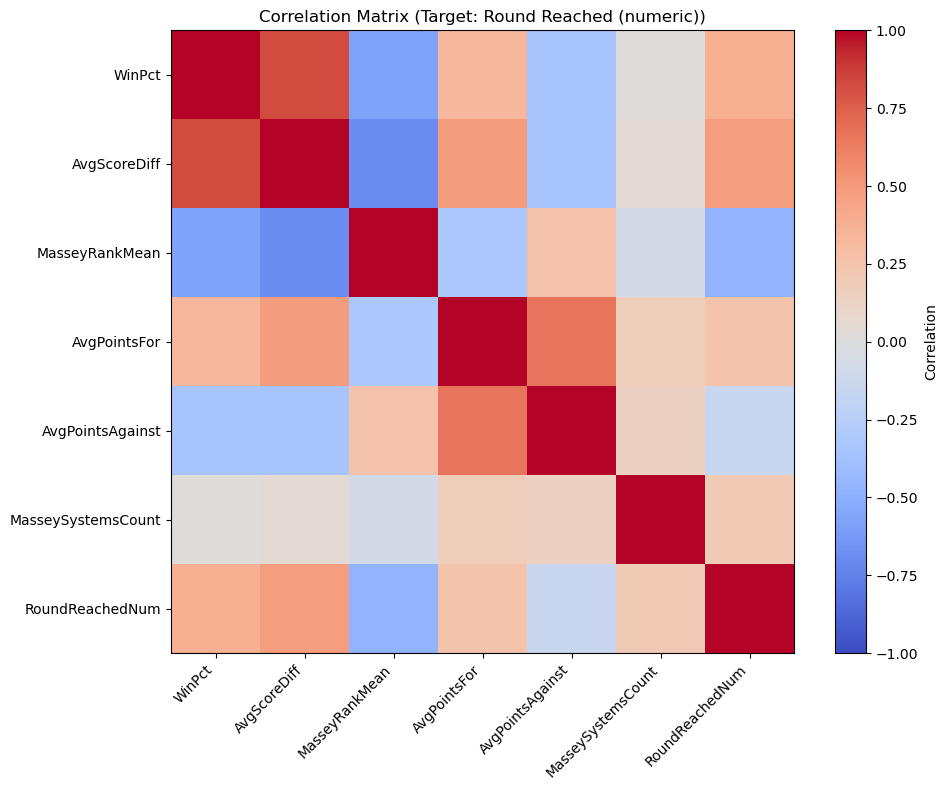

                    WinPct  AvgScoreDiff  MasseyRankMean  AvgPointsFor  \
WinPct               1.000         0.821          -0.574         0.333   
AvgScoreDiff         0.821         1.000          -0.688         0.480   
MasseyRankMean      -0.574        -0.688           1.000        -0.322   
AvgPointsFor         0.333         0.480          -0.322         1.000   
AvgPointsAgainst    -0.349        -0.346           0.260         0.656   
MasseySystemsCount   0.009         0.048          -0.071         0.168   
RoundReachedNum      0.377         0.471          -0.469         0.255   

                    AvgPointsAgainst  MasseySystemsCount  RoundReachedNum  
WinPct                        -0.349               0.009            0.377  
AvgScoreDiff                  -0.346               0.048            0.471  
MasseyRankMean                 0.260              -0.071           -0.469  
AvgPointsFor                   0.656               0.168            0.255  
AvgPointsAgainst           

In [3]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

# 1) Load data (metrics.csv)
candidate_paths = [
    Path("metrics.csv"),
    Path("processed/metrics.csv"),
    Path("data/processed/metrics.csv"),
]
metrics_path = next((p for p in candidate_paths if p.is_file()), None)
if metrics_path is None:
    raise FileNotFoundError("Could not find metrics.csv in expected locations.")

df = pd.read_csv(metrics_path)
print(f"Loaded: {metrics_path.resolve()}")

# 2) Build SeedNum + seed groups (1-4, 5-8, 9-12, 13-16)
if "SeedNum" not in df.columns:
    if "Seed" in df.columns:
        df["SeedNum"] = pd.to_numeric(df["Seed"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
    else:
        raise ValueError("No seed information found. Expected 'SeedNum' or 'Seed'.")

df["SeedNum"] = pd.to_numeric(df["SeedNum"], errors="coerce")
df = df[df["SeedNum"].between(1, 16, inclusive="both")].copy()

seed_labels = ["1-4", "5-8", "9-12", "13-16"]
df["SeedGroup"] = pd.cut(
    df["SeedNum"],
    bins=[0, 4, 8, 12, 16],
    labels=seed_labels,
    include_lowest=True
)

# 3) Choose best available tournament outcome column
outcome_col = None
display_name = None

if "RoundReachedNum" in df.columns and pd.api.types.is_numeric_dtype(df["RoundReachedNum"]):
    outcome_col = "RoundReachedNum"
    display_name = "Round Reached (numeric)"
elif "RoundReached" in df.columns:
    df["_RoundReachedNumDerived"] = pd.to_numeric(
        df["RoundReached"].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce"
    )
    if df["_RoundReachedNumDerived"].notna().any():
        outcome_col = "_RoundReachedNumDerived"
        display_name = "Round Reached (derived from RoundReached)"
elif "TourneyWins" in df.columns and pd.api.types.is_numeric_dtype(df["TourneyWins"]):
    outcome_col = "TourneyWins"
    display_name = "Tournament Wins"
elif "MadeTournament" in df.columns and pd.api.types.is_numeric_dtype(df["MadeTournament"]):
    outcome_col = "MadeTournament"
    display_name = "Made Tournament (0/1)"
else:
    raise ValueError("Could not find a valid tournament outcome column.")

corr_df = df.copy()

candidate_cols = [
    "WinPct", "AvgScoreDiff", "MasseyRankMean", "AvgPointsFor", 
    "AvgPointsAgainst", "MasseySystemsCount", outcome_col
]

corr_cols = [
    c for c in candidate_cols
    if c in corr_df.columns and pd.api.types.is_numeric_dtype(corr_df[c])
]

if len(corr_cols) < 2:
    raise ValueError("Need at least 2 numeric columns for correlation matrix.")

corr_matrix = corr_df[corr_cols].corr(numeric_only=True)

# Plot heatmap with matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title(f"Correlation Matrix (Target: {display_name})")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

## Exploring Cinderella Candidates

The next plot compares regular-season strength with tournament expectation. This helps show whether lower-seeded teams that become Cinderella teams already looked stronger than their seeds suggested before the tournament started.

Loaded: C:\Users\potat\Desktop\STAT486_FinalProject\data\metrics.csv


C:\Users\potat\AppData\Local\Temp\ipykernel_3448\3067510363.py:144: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c_plot = c_series.astype("object").fillna("Unknown")


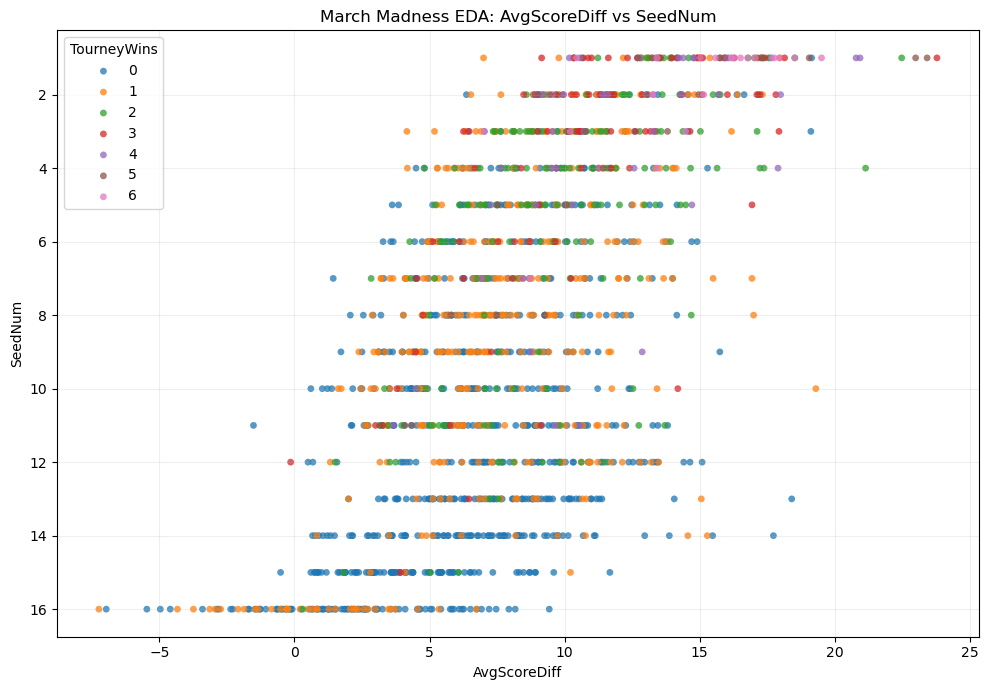

In [6]:
# 1) Load metrics.csv (robust paths)
candidate_paths = [
    Path("metrics.csv"),
    Path("processed/metrics.csv"),
    Path("data/processed/metrics.csv"),
]
metrics_path = next((p for p in candidate_paths if p.is_file()), None)
if metrics_path is None:
    raise FileNotFoundError(f"Could not find metrics.csv in: {candidate_paths}")

df = pd.read_csv(metrics_path)
print(f"Loaded: {metrics_path.resolve()}")

# 2) Flexible column matching helpers
def _norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

def find_col(columns, aliases=None, include=None, exclude=None, numeric_only=False, data=None):
    aliases = aliases or []
    include = include or []
    exclude = exclude or []

    norm_map = {_norm(c): c for c in columns}

    # alias exact/near-exact match first
    for a in aliases:
        key = _norm(a)
        if key in norm_map:
            c = norm_map[key]
            if numeric_only and data is not None and not pd.api.types.is_numeric_dtype(data[c]):
                continue
            return c

    # keyword match fallback
    for c in columns:
        cn = _norm(c)
        if include and not all(k in cn for k in include):
            continue
        if exclude and any(k in cn for k in exclude):
            continue
        if numeric_only and data is not None and not pd.api.types.is_numeric_dtype(data[c]):
            continue
        return c
    return None

cols = df.columns.tolist()

# 3) Identify candidate columns
score_margin_col = find_col(
    cols,
    aliases=["AvgScoreDiff", "ScoreDiff", "ScoringMargin", "PointDiff", "Margin"],
    include=["score", "diff"],
    numeric_only=True,
    data=df
) or find_col(cols, include=["point", "diff"], numeric_only=True, data=df)

win_pct_col = find_col(
    cols,
    aliases=["WinPct", "WinPercentage", "Win_Percentage", "Win%"],
    include=["win", "pct"],
    numeric_only=True,
    data=df
)

ranking_col = find_col(
    cols,
    aliases=["MasseyRankMean", "MasseyRankMedian", "OrdinalRank", "Rank", "Rating"],
    include=["rank"],
    numeric_only=True,
    data=df
) or find_col(cols, include=["massey"], numeric_only=True, data=df)

seed_num_col = find_col(
    cols,
    aliases=["SeedNum", "SeedNumber"],
    include=["seed"],
    numeric_only=True,
    data=df
)

seed_text_col = find_col(
    cols,
    aliases=["Seed"],
    include=["seed"],
    numeric_only=False,
    data=df
)

# derive numeric seed if needed
if seed_num_col is None and seed_text_col is not None:
    df["_SeedNumDerived"] = pd.to_numeric(
        df[seed_text_col].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce"
    )
    seed_num_col = "_SeedNumDerived"

# color variable candidates
cinderella_col = find_col(
    cols,
    aliases=["Cinderella", "CinderellaLabel", "IsCinderella", "CinderellaFlag"],
    include=["cinderella"],
    numeric_only=False,
    data=df
)

success_col = (
    find_col(cols, aliases=["TourneyWins", "TournamentWins"], include=["tourney", "wins"], numeric_only=True, data=df)
    or find_col(cols, aliases=["RoundReachedNum"], include=["round"], numeric_only=True, data=df)
    or find_col(cols, aliases=["MadeTournament"], include=["made", "tournament"], numeric_only=True, data=df)
)

# 4) Pick a meaningful pair automatically
if score_margin_col and seed_num_col:
    x_col, y_col = score_margin_col, seed_num_col
elif win_pct_col and seed_num_col:
    x_col, y_col = win_pct_col, seed_num_col
elif ranking_col and seed_num_col:
    x_col, y_col = ranking_col, seed_num_col
elif score_margin_col and ranking_col:
    x_col, y_col = score_margin_col, ranking_col
else:
    numeric_fallback = [c for c in df.select_dtypes(include="number").columns if c not in {"Season", "TeamID"}]
    if len(numeric_fallback) < 2:
        raise ValueError("Not enough numeric columns to plot.")
    x_col, y_col = numeric_fallback[0], numeric_fallback[1]

color_col = cinderella_col if cinderella_col in df.columns else success_col

# 5) Build plotting dataframe
plot_cols = [x_col, y_col] + ([color_col] if color_col and color_col in df.columns else [])
plot_df = df[plot_cols].copy()
plot_df = plot_df.dropna(subset=[x_col, y_col])

# 6) Scatterplot (matplotlib only)
fig, ax = plt.subplots(figsize=(10, 7))

used_color = False
if color_col and color_col in plot_df.columns and plot_df[color_col].notna().any():
    c_series = plot_df[color_col]

    # categorical or low-cardinality -> legend
    if (not pd.api.types.is_numeric_dtype(c_series)) or (c_series.nunique(dropna=True) <= 8):
        used_color = True
        c_plot = c_series.astype("object").fillna("Unknown")
        categories = sorted(c_plot.unique(), key=lambda v: str(v))
        cmap = plt.get_cmap("tab10")

        for i, cat in enumerate(categories):
            mask = c_plot == cat
            ax.scatter(
                plot_df.loc[mask, x_col],
                plot_df.loc[mask, y_col],
                s=24,
                alpha=0.75,
                color=cmap(i % 10),
                label=str(cat),
                edgecolors="none"
            )
        ax.legend(title=color_col, frameon=True)
    else:
        # continuous color -> colorbar
        used_color = True
        sc = ax.scatter(
            plot_df[x_col],
            plot_df[y_col],
            c=c_series,
            cmap="viridis",
            s=24,
            alpha=0.75,
            edgecolors="none"
        )
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(color_col)

if not used_color:
    ax.scatter(plot_df[x_col], plot_df[y_col], s=24, alpha=0.75, color="steelblue", edgecolors="none")

ax.set_title(f"March Madness EDA: {x_col} vs {y_col}")
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)

# Invert axis for seed/rank so stronger teams appear higher
if "seed" in _norm(y_col) or ("rank" in _norm(y_col) and y_col == ranking_col):
    ax.invert_yaxis()

ax.grid(alpha=0.2)
plt.tight_layout()

# 7) Print the figure
plt.show()

## Cinderella Interpretation

This scatterplot suggests that teams with stronger scoring margins generally receive better seeds, but there is still substantial spread within each seed band. The highlighted Cinderella teams tend to come from worse seed ranges while still showing respectable regular-season quality, which supports the idea that some Cinderella teams may be under-seeded rather than purely random surprises.

## Cinderella Frequency

Because the project focuses on identifying rare tournament overperformers, it is important to understand how uncommon these teams are in the full dataset. This distribution helps frame the difficulty of the prediction problem.

Loaded: C:\Users\potat\Desktop\STAT486_FinalProject\data\metrics.csv  |  shape=(8346, 34)

Cinderella teams: 53 / 8,346 (0.64%)

Definition used:
- Condition A: SeedNum >= 10 AND TourneyWins >= 2 (used as Sweet 16 proxy)
- Condition B: SeedNum >= 11 AND TourneyWins >= 2


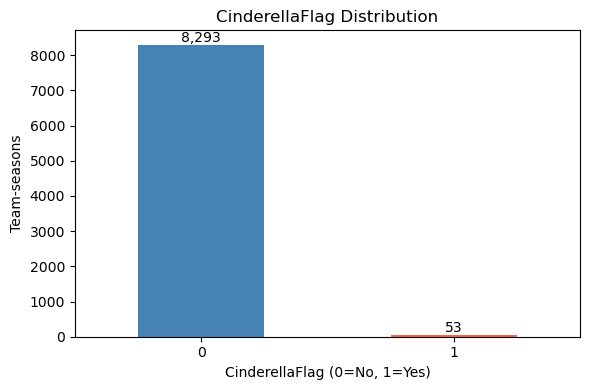

In [7]:
# 1) Load metrics.csv
candidate_paths = [
    Path("metrics.csv"),
    Path("processed/metrics.csv"),
    Path("data/processed/metrics.csv"),
]
metrics_path = next((p for p in candidate_paths if p.is_file()), None)
if metrics_path is None:
    raise FileNotFoundError(f"Could not find metrics.csv in: {candidate_paths}")

df = pd.read_csv(metrics_path)
print(f"Loaded: {metrics_path.resolve()}  |  shape={df.shape}")

# 2) Detect best available seed + tournament-success columns
def _norm(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())

def find_col(columns, aliases=None, include=None, numeric_only=False, data=None):
    aliases = aliases or []
    include = include or []
    norm_map = {_norm(c): c for c in columns}

    for a in aliases:
        key = _norm(a)
        if key in norm_map:
            c = norm_map[key]
            if numeric_only and data is not None and not pd.api.types.is_numeric_dtype(data[c]):
                continue
            return c

    for c in columns:
        cn = _norm(c)
        if include and not all(k in cn for k in include):
            continue
        if numeric_only and data is not None and not pd.api.types.is_numeric_dtype(data[c]):
            continue
        return c
    return None

cols = df.columns.tolist()

# Seed (prefer numeric, derive from text if needed)
seed_num_col = find_col(cols, aliases=["SeedNum", "SeedNumber"], include=["seed"], numeric_only=True, data=df)
seed_text_col = find_col(cols, aliases=["Seed"], include=["seed"], numeric_only=False, data=df)

if seed_num_col is None and seed_text_col is not None:
    df["_SeedNumDerived"] = pd.to_numeric(
        df[seed_text_col].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce"
    )
    seed_num_col = "_SeedNumDerived"

if seed_num_col is None:
    raise ValueError("No usable seed column found (expected SeedNum or Seed).")

# Tournament success candidates
wins_col = (
    find_col(cols, aliases=["TourneyWins", "TournamentWins", "NCAATourneyWins"], include=["tourney", "wins"], numeric_only=True, data=df)
    or find_col(cols, include=["tournament", "wins"], numeric_only=True, data=df)
)
round_num_col = find_col(cols, aliases=["RoundReachedNum"], include=["round"], numeric_only=True, data=df)
round_text_col = find_col(cols, aliases=["RoundReached"], include=["round"], numeric_only=False, data=df)

# Build round number if only text exists
if round_num_col is None and round_text_col is not None:
    df["_RoundNumDerived"] = pd.to_numeric(
        df[round_text_col].astype(str).str.extract(r"(\d+)")[0],
        errors="coerce"
    )
    if df["_RoundNumDerived"].notna().any():
        round_num_col = "_RoundNumDerived"

seed_num = pd.to_numeric(df[seed_num_col], errors="coerce")
wins = pd.to_numeric(df[wins_col], errors="coerce") if wins_col is not None else pd.Series(pd.NA, index=df.index, dtype="float")
round_num = pd.to_numeric(df[round_num_col], errors="coerce") if round_num_col is not None else pd.Series(pd.NA, index=df.index, dtype="float")

# Decide Sweet 16 proxy
# If rounds look canonical (max <= 8), use RoundReachedNum >= 3; otherwise fall back to TourneyWins >= 2.
if round_num.notna().any() and round_num.max() <= 8:
    sweet16_mask = round_num >= 3
    sweet16_note = f"{round_num_col} >= 3"
elif wins.notna().any():
    sweet16_mask = wins >= 2
    sweet16_note = f"{wins_col} >= 2 (used as Sweet 16 proxy)"
else:
    raise ValueError("No usable tournament-success column found (need TourneyWins and/or RoundReachedNum).")

# 3) Create CinderellaFlag (0/1)
# Definition:
#   (seed >= 10 and reached Sweet 16 proxy) OR (seed >= 11 and won >= 2 games)
if wins.notna().any():
    cinderella_mask = ((seed_num >= 10) & sweet16_mask) | ((seed_num >= 11) & (wins >= 2))
    wins_note = f"{wins_col} >= 2"
else:
    cinderella_mask = ((seed_num >= 10) & sweet16_mask) | ((seed_num >= 11) & sweet16_mask)
    wins_note = f"{sweet16_note} (wins unavailable)"

df["CinderellaFlag"] = cinderella_mask.fillna(False).astype(int)

# 4) Print count + percentage
c_count = int(df["CinderellaFlag"].sum())
total = len(df)
c_pct = (c_count / total) * 100 if total else 0.0

print(f"\nCinderella teams: {c_count:,} / {total:,} ({c_pct:.2f}%)")
print("\nDefinition used:")
print(f"- Condition A: {seed_num_col} >= 10 AND {sweet16_note}")
print(f"- Condition B: {seed_num_col} >= 11 AND {wins_note}")

# Optional visualization
flag_counts = df["CinderellaFlag"].value_counts().reindex([0, 1], fill_value=0)
ax = flag_counts.plot(kind="bar", color=["steelblue", "tomato"], figsize=(6, 4), rot=0)
ax.set_title("CinderellaFlag Distribution")
ax.set_xlabel("CinderellaFlag (0=No, 1=Yes)")
ax.set_ylabel("Team-seasons")
for i, v in enumerate(flag_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Cinderella Interpretation

The distribution confirms that Cinderella team-seasons make up only a very small fraction of the dataset. This means the final prediction task will be highly imbalanced, which has important implications for later model selection and evaluation.

## Final Reflection

A major challenge in this project is defining a “Cinderella” in a way that is intuitive but also reproducible for machine learning. Different choices based on seed, tournament wins, or round reached would produce slightly different targets. The EDA suggests that seed and ranking variables explain much of tournament success, but regular-season strength measures may still help identify under-seeded teams with upset potential. The next step is to use these insights to select predictors and build supervised models while carefully avoiding leakage and addressing class imbalance.